# Tuning hyperparameters

Set directory

In [1]:
import sys
import os

# Find the project root (Speciale_Kode)
current_dir = os.getcwd()
project_root = current_dir

# Looks for "Speciale_Kode" folder:
while os.path.basename(project_root) != "Speciale_Kode":
    project_root = os.path.dirname(project_root)

# Add to Python path
if project_root not in sys.path:
    sys.path.append(project_root)

In [2]:
# Run this as the first cell after restarting
from Modules.Load_RF_forecast_models import load_rf_models
rf_models = load_rf_models("Christine - laptop")

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from C:\Users\Christine\_netrc.
wandb: Downloading large artifact 'rf_OffshoreWindPower_DK1:latest', 1817.80MB. 2 files...
wandb:   2 of 2 files downloaded.  
Done. 00:00:00.9 (2077.5MB/s)
c:\Users\Christine\anaconda3\envs\ds809\lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeRegressor from version 1.7.2 when using version 1.7.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\Christine\anaconda3\envs\ds809\lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator RandomForestRegressor from version 1.7.2 when using version 1.7.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-lear

✓ Loaded RF model for OffshoreWindPower_DK1 from C:\Users\Christine\Documents\Python\Personlig\OffshoreWindPower_DK1


wandb: Downloading large artifact 'rf_OffshoreWindPower_DK2:latest', 1809.79MB. 2 files...
wandb:   2 of 2 files downloaded.  
Done. 00:00:00.5 (3731.5MB/s)


✓ Loaded RF model for OffshoreWindPower_DK2 from C:\Users\Christine\Documents\Python\Personlig\OffshoreWindPower_DK2


wandb: Downloading large artifact 'rf_OnshoreWindPower_DK1:latest', 1817.91MB. 2 files...
wandb:   2 of 2 files downloaded.  
Done. 00:00:00.5 (3635.8MB/s)


✓ Loaded RF model for OnshoreWindPower_DK1 from C:\Users\Christine\Documents\Python\Personlig\OnshoreWindPower_DK1


wandb: Downloading large artifact 'rf_OnshoreWindPower_DK2:latest', 1815.11MB. 2 files...
wandb:   2 of 2 files downloaded.  
Done. 00:00:00.4 (4144.1MB/s)


✓ Loaded RF model for OnshoreWindPower_DK2 from C:\Users\Christine\Documents\Python\Personlig\OnshoreWindPower_DK2


wandb: Downloading large artifact 'rf_SolarPower_DK1:latest', 1666.36MB. 2 files...
wandb:   2 of 2 files downloaded.  
Done. 00:00:00.4 (4272.7MB/s)


✓ Loaded RF model for SolarPower_DK1 from C:\Users\Christine\Documents\Python\Personlig\SolarPower_DK1


wandb: Downloading large artifact 'rf_SolarPower_DK2:latest', 1580.46MB. 2 files...
wandb:   2 of 2 files downloaded.  
Done. 00:00:00.4 (4402.4MB/s)


✓ Loaded RF model for SolarPower_DK2 from C:\Users\Christine\Documents\Python\Personlig\SolarPower_DK2


wandb: Downloading large artifact 'rf_TotalProduction_DK1:latest', 1817.61MB. 2 files...
wandb:   2 of 2 files downloaded.  
Done. 00:00:00.4 (4307.1MB/s)


✓ Loaded RF model for TotalProduction_DK1 from C:\Users\Christine\Documents\Python\Personlig\TotalProduction_DK1


wandb: Downloading large artifact 'rf_TotalProduction_DK2:latest', 1817.23MB. 2 files...
wandb:   2 of 2 files downloaded.  
Done. 00:00:00.5 (4011.6MB/s)


✓ Loaded RF model for TotalProduction_DK2 from C:\Users\Christine\Documents\Python\Personlig\TotalProduction_DK2

✓ Successfully loaded 8 RF models


Load data:

In [3]:
from Modules.read_data import read_data

(
    DK1_train, 
    DK1_test, 
    DK2_train, 
    DK2_test,
    DK1_train_weather, 
    DK1_test_weather, 
    DK2_train_weather, 
    DK2_test_weather
    ) = read_data("combined_data_cleaned_v5.csv")

Notebook_dir: c:\Users\Christine\Documents\Python\Speciale_Kode\Modules
Python_dir: c:\Users\Christine\Documents\Python\Speciale_Kode
Data_folder: c:\Users\Christine\Documents\Python\Speciale_Kode\Data
Training data shape (DK1): (78888, 38)
Test data shape (DK1): (8760, 38)
Test set fraction (DK1): 9.99%
Training data shape (DK2): (78888, 38)
Test data shape (DK2): (8760, 38)
Test set fraction (DK2): 9.99%


## Import model and choose parameter search grid

In [4]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import numpy as np
# Import model library. E.g.:
# from sklearn.svm import SVR
from xgboost import XGBRegressor
from Modules.Load_RF_forecast_models import load_rf_models

# load_rf_models currently supports only the optional timeout argument.
rf_models = load_rf_models("Christine - laptop")

# Initialize model:
model = XGBRegressor()

# Keep at least one number in each list to avoid wrong calculation of total combinations
# If a parameter is not relevant just set a 0 in the list
param_grid = {
    'max_depth':       [3, 5, 7],
    'learning_rate':   [0.05, 0.1, 0.2],
    'n_estimators':    [200, 400, 600],  
    'subsample':       [0.7, 0.9, 1.0],  
    'colsample_bytree':[0.7, 0.9, 1.0],   
}

num_combinations = np.prod([len(v) for v in param_grid.values()])
print(f"Total number of combinations to test: {num_combinations}")


Total number of combinations to test: 243


## Choose validation setup


**Setup 1**

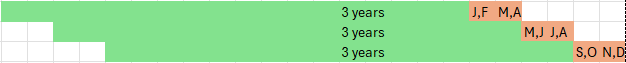

For this setup, val_start in the first fold is fixed at 2024-01-01 00:00:00 and train_end the hour before that (2023-12-31 23:00:00). train_start, val_end and remaining fold values are computed using train_window, predict_horizon and stride.

**Setup 2**



For this setup, val_end in the first fold is fixed at 2024-12-31 23:00:00. train_start, train_end and val_start are computed using train_window and predict_horizon. There is only one fold, so stride has no function.

Write the desired setup number as "split_setup" in the hyper_param_split() function below.

## Find best parameters

### Hyperparameter search for DK1:

Remember to give the right path to save the csv with results!

In [5]:
from skforecast.exceptions import IgnoredArgumentWarning
import warnings
warnings.filterwarnings("ignore", category=UserWarning, message="Raw feature columns are present")
warnings.filterwarnings("ignore", category=UserWarning, message="Some categorized features not in dataset")
warnings.filterwarnings("ignore", category=UserWarning, message="X does not have valid feature names")
warnings.simplefilter('ignore', category=IgnoredArgumentWarning)

In [6]:
# from Modules.Cross_Validation_runner import run_cross_validation
from Modules.Validation2 import run_cross_validation
import itertools
import pandas as pd
import os

print(f"Total number of combinations to test: {num_combinations}")

param_names = list(param_grid.keys())
param_values = list(param_grid.values())
all_combinations = list(itertools.product(*param_values))

split_setup = 2

results = []
for comb_number, combination in enumerate(all_combinations, start=1):
    params = dict(zip(param_names, combination))

    print(f"\nCombination {comb_number}/{num_combinations}: {params}")

    model.set_params(**params)
    combination_results = run_cross_validation(
        model = model,
        dataset = DK1_train,
        dk_zone = "DK1",
        split_setup = split_setup,
        train_window = 3 * 8760,        # 8760 hours = 1 year
        val_window = 1 * 8784,
        val_start = "2024-01-01 00:00:00",
        predict_period = 4 * 168,     # 168 hours = 1 week
        stride = 13 * 168,               # stride between predict_periods              
        use_scaler = False,              # Set to True for models that needs feature scaling
        print_fold_results = False,     # Print weekly SMAPE values for each fold in each combination?
        plot = False,                   # Plot daily SMAPE values for the entire predict_horizon for each combination?
        rf_models = rf_models
    )

    row = {
        **params,
        "avg_smape": combination_results["overall_avg_weekly_smape"],
        "avg_weekly_rmse": combination_results["overall_avg_weekly_rmse"],
        "avg_weekly_mae": combination_results["overall_avg_weekly_mae"],
        "avg_weekly_smape": combination_results["overall_avg_weekly_smape"],
        "avg_daily_rmse": combination_results["overall_avg_daily_rmse"],
        "avg_daily_mae": combination_results["overall_avg_daily_mae"],
        "avg_daily_smape": combination_results["overall_avg_daily_smape"],
        "avg_smape_day_1": combination_results["avg_smape_day_1"],
        "avg_smape_day_2": combination_results["avg_smape_day_2"],
        "avg_smape_day_3": combination_results["avg_smape_day_3"],
        "avg_smape_day_4": combination_results["avg_smape_day_4"],
        "avg_smape_day_5": combination_results["avg_smape_day_5"],
        "avg_smape_day_6": combination_results["avg_smape_day_6"],
        "avg_smape_day_7": combination_results["avg_smape_day_7"]
    }
    results.append(row)

# Save the search results as a CSV file in chosen folder path:
results_df = pd.DataFrame(results).sort_values("avg_smape")
folder = os.path.join(project_root, "Shallow learners")
folder = os.path.join(folder, "Random Forest")
base_filename = f"DK1_hyperparameter_results_xgb_split{split_setup}.csv"          # Name the results file
filename = os.path.join(folder, base_filename)

# adds a number to the filename if a file with same name already exists:
counter = 1     
while os.path.exists(filename):
    filename = os.path.join(folder, f"{base_filename}_{counter}.csv")
    counter += 1
results_df.to_csv(filename, index=False, decimal=",")

print(f"\nResults saved to: {filename}")
# print(results_df.to_string(index=False))


c:\Users\Christine\anaconda3\envs\ds809\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Total number of combinations to test: 243

Combination 1/243: {'max_depth': 3, 'learning_rate': 0.05, 'n_estimators': 200, 'subsample': 0.7, 'colsample_bytree': 0.7}
Training fold details: train_start=2021-01-01 00:00:00, train_end=2023-12-31 23:00:00, hours=26280, rows=26280, features=36
Model trained in 0.66s. Now validating on 4 folds...

Average RMSE across all weeks in all folds: 353.881

Average MAE across all weeks in all folds: 258.598

Average SMAPE across all weeks in all folds: 67.142

Combination 2/243: {'max_depth': 3, 'learning_rate': 0.05, 'n_estimators': 200, 'subsample': 0.7, 'colsample_bytree': 0.9}
Training fold details: train_start=2021-01-01 00:00:00, train_end=2023-12-31 23:00:00, hours=26280, rows=26280, features=36
Model trained in 0.76s. Now validating on 4 folds...

Average RMSE across all weeks in all folds: 356.321

Average MAE across all weeks in all folds: 259.623

Average SMAPE across all weeks in all folds: 67.401

Combination 3/243: {'max_depth': 3, 'le

### Hyperparameter search for DK2:

Remember to give the right path to save the csv with resutls!

In [7]:
# from Modules.Cross_Validation_runner import run_cross_validation
from Modules.Validation2 import run_cross_validation
import itertools
import pandas as pd
import os

print(f"Total number of combinations to test: {num_combinations}")

param_names = list(param_grid.keys())
param_values = list(param_grid.values())
all_combinations = list(itertools.product(*param_values))

split_setup = 2

results = []
for comb_number, combination in enumerate(all_combinations, start=1):
    params = dict(zip(param_names, combination))

    print(f"\nCombination {comb_number}/{num_combinations}: {params}")

    model.set_params(**params)
    combination_results = run_cross_validation(
        model = model,
        dataset = DK2_train,
        dk_zone = "DK2",
        split_setup = split_setup,
        train_window = 3 * 8760,        # 8760 hours = 1 year
        val_window = 1 * 8784,
        val_start = "2024-01-01 00:00:00",
        predict_period = 4 * 168,     # 168 hours = 1 week
        stride = 13 * 168,               # stride between predict_periods              
        use_scaler = False,              # Set to True for models that needs feature scaling
        print_fold_results = False,     # Print weekly SMAPE values for each fold in each combination?
        plot = False,                   # Plot daily SMAPE values for the entire predict_horizon for each combination?
        rf_models = rf_models
    )

    row = {
        **params,
        "avg_smape": combination_results["overall_avg_weekly_smape"],
        "avg_weekly_rmse": combination_results["overall_avg_weekly_rmse"],
        "avg_weekly_mae": combination_results["overall_avg_weekly_mae"],
        "avg_weekly_smape": combination_results["overall_avg_weekly_smape"],
        "avg_daily_rmse": combination_results["overall_avg_daily_rmse"],
        "avg_daily_mae": combination_results["overall_avg_daily_mae"],
        "avg_daily_smape": combination_results["overall_avg_daily_smape"],
        "avg_smape_day_1": combination_results["avg_smape_day_1"],
        "avg_smape_day_2": combination_results["avg_smape_day_2"],
        "avg_smape_day_3": combination_results["avg_smape_day_3"],
        "avg_smape_day_4": combination_results["avg_smape_day_4"],
        "avg_smape_day_5": combination_results["avg_smape_day_5"],
        "avg_smape_day_6": combination_results["avg_smape_day_6"],
        "avg_smape_day_7": combination_results["avg_smape_day_7"]
    }
    results.append(row)

# Save the search results as a CSV file in chosen folder path:
results_df = pd.DataFrame(results).sort_values("avg_smape")
folder = os.path.join(project_root, "Shallow learners")
folder = os.path.join(folder, "Random Forest")
base_filename = f"DK2_hyperparameter_results_xgb_split{split_setup}.csv"
filename = os.path.join(folder, base_filename)

# adds a number to the filename if a file with same name already exists:
counter = 1
while os.path.exists(filename):
    filename = os.path.join(folder, f"{base_filename}_{counter}.csv")
    counter += 1
results_df.to_csv(filename, index=False, decimal=",")

print(f"\nResults saved to: {filename}")
# print(results_df.to_string(index=False))


Total number of combinations to test: 243

Combination 1/243: {'max_depth': 3, 'learning_rate': 0.05, 'n_estimators': 200, 'subsample': 0.7, 'colsample_bytree': 0.7}
Training fold details: train_start=2021-01-01 00:00:00, train_end=2023-12-31 23:00:00, hours=26280, rows=26280, features=36
Model trained in 0.52s. Now validating on 4 folds...

Average RMSE across all weeks in all folds: 372.616

Average MAE across all weeks in all folds: 266.065

Average SMAPE across all weeks in all folds: 64.608

Combination 2/243: {'max_depth': 3, 'learning_rate': 0.05, 'n_estimators': 200, 'subsample': 0.7, 'colsample_bytree': 0.9}
Training fold details: train_start=2021-01-01 00:00:00, train_end=2023-12-31 23:00:00, hours=26280, rows=26280, features=36
Model trained in 0.68s. Now validating on 4 folds...

Average RMSE across all weeks in all folds: 374.648

Average MAE across all weeks in all folds: 267.192

Average SMAPE across all weeks in all folds: 64.538

Combination 3/243: {'max_depth': 3, 'le

## Train and Test Final Model

In [8]:
import pandas as pd
from Modules.Validation2 import _build_validation_folds

price_zone = "DK2"

if price_zone == "DK1":
    train_data = DK1_train
    test_data = DK1_test
else:
    train_data = DK2_train
    test_data = DK2_test

dataset = pd.concat([train_data, test_data], ignore_index=True)

folds = _build_validation_folds(
    data=dataset,
    train_window=len(train_data),        # 8760 hours = 1 year
    val_window=len(test_data),
    val_start=str(test_data["Time"].min()),
    predict_period=len(test_data),         # 168 hours = 1 week
    stride=len(test_data),               # stride between predict_periods              
)

train_start = folds[0]["train_start"]
train_end = folds[0]["train_end"]
num_folds = len(folds)
val_start = folds[0]["val_start"]
val_end = val_start + pd.Timedelta(hours=len(test_data) - 1)
prediction_period = folds[0]["val_end"] - folds[0]["val_start"] + pd.Timedelta(hours=1)

print(f"Fold {folds[0]['fold']} train start: {train_start} - train end: {train_end}")
print(f"Number of folds: {num_folds}")
print(f"Test window start: {val_start} - test window end: {val_end}")
print(f"Prediction period: {prediction_period}")
for fold in range(len(folds)):
    print(f"Fold {folds[fold]['fold']} test start: {folds[fold]['val_start']} - test end: {folds[fold]['val_end']}")

Fold 1 train start: 2016-01-02 00:00:00 - train end: 2024-12-31 23:00:00
Number of folds: 1
Test window start: 2025-01-01 00:00:00 - test window end: 2025-12-31 23:00:00
Prediction period: 365 days 00:00:00
Fold 1 test start: 2025-01-01 00:00:00 - test end: 2025-12-31 23:00:00


Training final model. This may take a while...
Training fold details: train_start=2016-01-02 00:00:00, train_end=2024-12-31 23:00:00, hours=78888, rows=78888, features=36
Model trained in 3.28s. Now validating on 1 folds...

Average RMSE across all weeks in all folds: 398.461

Average MAE across all weeks in all folds: 321.763

Average SMAPE across all weeks in all folds: 66.186


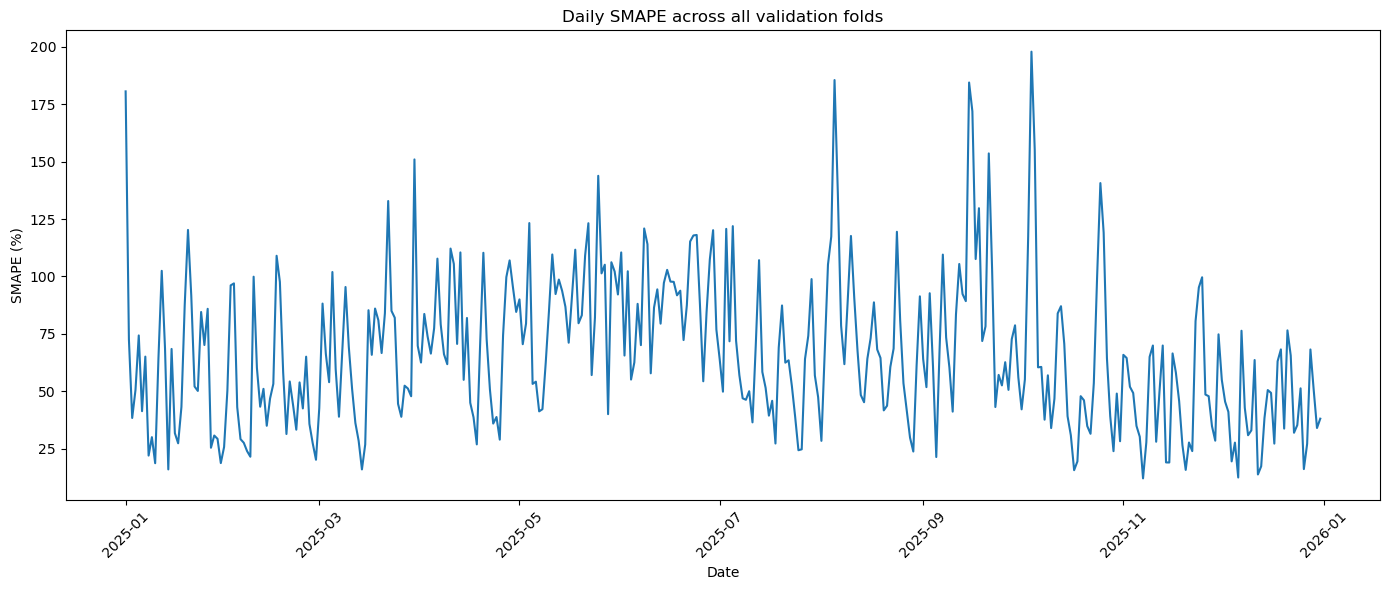


Results saved to: c:\Users\Christine\Documents\Python\Speciale_Kode\Shallow learners\XGBoost\DK1_final_XGB_results.csv
Model persistence disabled (save_model_to_disk=False).


In [10]:
import os
from pathlib import Path
import joblib
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from Modules.Validation2 import run_cross_validation

# Set price zone and parameters
# ========================
price_zone = "DK1"
retrain_model = True  # Set True only when you want to retrain from scratch
save_model_to_disk = False  # Keep False to avoid multi-GB model files

params = {
    "max_depth": 5,
    "learning_rate": 0.05,
    "n_estimators": 400,
    "subsample": 1.0,
    "colsample_bytree": 1.0,
}
# =========================

if price_zone == "DK1":
    train_data = DK1_train
    test_data = DK1_test
else:
    train_data = DK2_train
    test_data = DK2_test

dataset = pd.concat([train_data, test_data], ignore_index=True)

# Save model in the same folder as this notebook/script (Random Forest folder)
model_dir = Path(project_root) / "Shallow learners" / "Random Forest"
model_dir.mkdir(parents=True, exist_ok=True)
model_path = model_dir / f"rf_final_{price_zone}.joblib"

results = []

if model_path.exists() and not retrain_model and save_model_to_disk:
    print(f"Loading existing trained model: {model_path}")
    model = joblib.load(model_path)
    print("Model loaded. Skipping retraining.")
else:
    print("Training final model. This may take a while...")
    model = XGBRegressor(**params)

    combination_results = run_cross_validation(
        model=model,
        dataset=dataset,
        dk_zone=price_zone,
        split_setup=2,  # ignored in Validation2 but safe to keep
        train_window=len(train_data),  # full training set
        val_window=len(test_data),     # full test set
        val_start=str(test_data["Time"].min()),
        predict_period=len(test_data), # one fold covering full test period
        stride=len(test_data),
        use_scaler=False,
        print_fold_results=False,
        plot=True,
        rf_models=rf_models,
    )

    # Extract the fitted model
    model = combination_results["model"]

    row = {
        **params,
        "avg_smape": combination_results["overall_avg_weekly_smape"],
        "avg_weekly_rmse": combination_results["overall_avg_weekly_rmse"],
        "avg_weekly_mae": combination_results["overall_avg_weekly_mae"],
        "avg_weekly_smape": combination_results["overall_avg_weekly_smape"],
        "avg_daily_rmse": combination_results["overall_avg_daily_rmse"],
        "avg_daily_mae": combination_results["overall_avg_daily_mae"],
        "avg_daily_smape": combination_results["overall_avg_daily_smape"],
        "avg_smape_day_1": combination_results["avg_smape_day_1"],
        "avg_smape_day_2": combination_results["avg_smape_day_2"],
        "avg_smape_day_3": combination_results["avg_smape_day_3"],
        "avg_smape_day_4": combination_results["avg_smape_day_4"],
        "avg_smape_day_5": combination_results["avg_smape_day_5"],
        "avg_smape_day_6": combination_results["avg_smape_day_6"],
        "avg_smape_day_7": combination_results["avg_smape_day_7"]
    }
    results.append(row)

    # Save metrics
    results_df = pd.DataFrame(results).sort_values("avg_smape")
    folder = os.path.join(project_root, "Shallow learners")
    folder = os.path.join(folder, "XGBoost")
    base_filename = f"{price_zone}_final_XGB_results.csv"
    filename = os.path.join(folder, base_filename)

    # Adds a number to the filename if a file with same name already exists
    counter = 1
    while os.path.exists(filename):
        filename = os.path.join(folder, f"{base_filename}_{counter}.csv")
        counter += 1
    results_df.to_csv(filename, index=False, decimal=",")
    print(f"\nResults saved to: {filename}")

    if save_model_to_disk:
        # Compression reduces disk usage considerably at the cost of slower save/load
        joblib.dump(model, model_path, compress=3)
        print(f"Trained model saved to: {model_path}")
    else:
        print("Model persistence disabled (save_model_to_disk=False).")

Training final model. This may take a while...
Training fold details: train_start=2016-01-02 00:00:00, train_end=2024-12-31 23:00:00, hours=78888, rows=78888, features=36
Model trained in 5.21s. Now validating on 1 folds...

Average RMSE across all weeks in all folds: 406.725

Average MAE across all weeks in all folds: 331.210

Average SMAPE across all weeks in all folds: 70.792


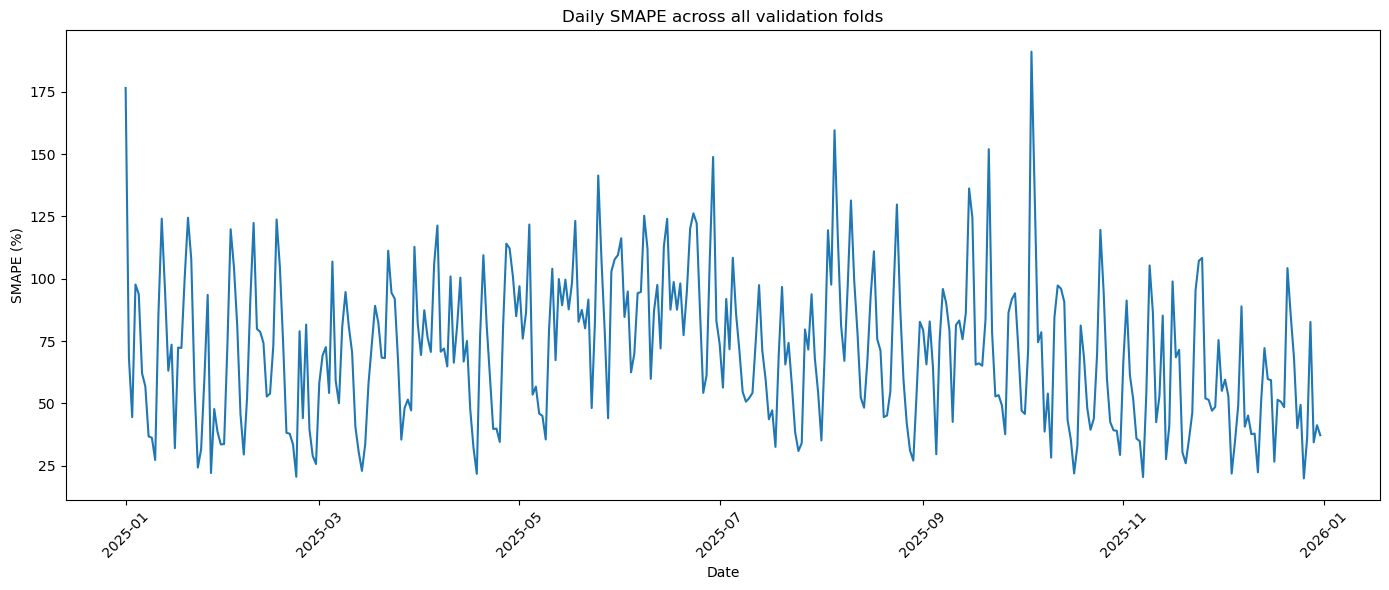


Results saved to: c:\Users\Christine\Documents\Python\Speciale_Kode\Shallow learners\XGBoost\DK2_final_XGB_results.csv
Model persistence disabled (save_model_to_disk=False).


In [11]:
import os
from pathlib import Path
import joblib
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from Modules.Validation2 import run_cross_validation

# Set price zone and parameters
# ========================
price_zone = "DK2"
retrain_model = True  # Set True only when you want to retrain from scratch
save_model_to_disk = False  # Keep False to avoid multi-GB model files

params = {
    "max_depth": 7,
    "learning_rate": 0.05,
    "n_estimators": 400,
    "subsample": 1.0,
    "colsample_bytree": 0.7,
}
# =========================

if price_zone == "DK1":
    train_data = DK1_train
    test_data = DK1_test
else:
    train_data = DK2_train
    test_data = DK2_test

dataset = pd.concat([train_data, test_data], ignore_index=True)

# Save model in the same folder as this notebook/script (Random Forest folder)
model_dir = Path(project_root) / "Shallow learners" / "Random Forest"
model_dir.mkdir(parents=True, exist_ok=True)
model_path = model_dir / f"rf_final_{price_zone}.joblib"

results = []

if model_path.exists() and not retrain_model and save_model_to_disk:
    print(f"Loading existing trained model: {model_path}")
    model = joblib.load(model_path)
    print("Model loaded. Skipping retraining.")
else:
    print("Training final model. This may take a while...")
    model = XGBRegressor(**params)

    combination_results = run_cross_validation(
        model=model,
        dataset=dataset,
        dk_zone=price_zone,
        split_setup=2,  # ignored in Validation2 but safe to keep
        train_window=len(train_data),  # full training set
        val_window=len(test_data),     # full test set
        val_start=str(test_data["Time"].min()),
        predict_period=len(test_data), # one fold covering full test period
        stride=len(test_data),
        use_scaler=False,
        print_fold_results=False,
        plot=True,
        rf_models=rf_models,
    )

    # Extract the fitted model
    model = combination_results["model"]

    row = {
        **params,
        "avg_smape": combination_results["overall_avg_weekly_smape"],
        "avg_weekly_rmse": combination_results["overall_avg_weekly_rmse"],
        "avg_weekly_mae": combination_results["overall_avg_weekly_mae"],
        "avg_weekly_smape": combination_results["overall_avg_weekly_smape"],
        "avg_daily_rmse": combination_results["overall_avg_daily_rmse"],
        "avg_daily_mae": combination_results["overall_avg_daily_mae"],
        "avg_daily_smape": combination_results["overall_avg_daily_smape"],
        "avg_smape_day_1": combination_results["avg_smape_day_1"],
        "avg_smape_day_2": combination_results["avg_smape_day_2"],
        "avg_smape_day_3": combination_results["avg_smape_day_3"],
        "avg_smape_day_4": combination_results["avg_smape_day_4"],
        "avg_smape_day_5": combination_results["avg_smape_day_5"],
        "avg_smape_day_6": combination_results["avg_smape_day_6"],
        "avg_smape_day_7": combination_results["avg_smape_day_7"]
    }
    results.append(row)

    # Save metrics
    results_df = pd.DataFrame(results).sort_values("avg_smape")
    folder = os.path.join(project_root, "Shallow learners")
    folder = os.path.join(folder, "XGBoost")
    base_filename = f"{price_zone}_final_XGB_results.csv"
    filename = os.path.join(folder, base_filename)

    # Adds a number to the filename if a file with same name already exists
    counter = 1
    while os.path.exists(filename):
        filename = os.path.join(folder, f"{base_filename}_{counter}.csv")
        counter += 1
    results_df.to_csv(filename, index=False, decimal=",")
    print(f"\nResults saved to: {filename}")

    if save_model_to_disk:
        # Compression reduces disk usage considerably at the cost of slower save/load
        joblib.dump(model, model_path, compress=3)
        print(f"Trained model saved to: {model_path}")
    else:
        print("Model persistence disabled (save_model_to_disk=False).")